In [1]:
%load_ext autoreload
%autoreload 2

%aimport -faiss
%aimport -PIL

import sys
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from hep_tracking.ann_models import FaissIVFFlat, FaissIVFPQ, HnswGraph
from hep_tracking.utils import calculate_recall

print("Zależności ANN załadowane pomyślnie!")

Zależności ANN załadowane pomyślnie!


In [2]:
data_dir = project_root / "data"
dataset_name = "dataset_hard_100k.npz"
candidates_name = "candidates_hard_100k.npz"

data_path = data_dir / dataset_name
candidates_path = data_dir / candidates_name

if not data_path.exists() or not candidates_path.exists():
    raise FileNotFoundError("Brak danych! Upewnij się, że wywołałeś `make candidates`.")

features = np.load(data_path)["X"]
n_queries = features.shape[0]

true_indices = np.load(candidates_path)["indices"]
k_neighbors = true_indices.shape[1]

print(f"Załadowano dane: {n_queries} punktów w przestrzeni {features.shape[1]}D")
print(f"Szukamy {k_neighbors} najbliższych sąsiadów.")

Załadowano dane: 99995 punktów w przestrzeni 5D
Szukamy 5 najbliższych sąsiadów.


In [3]:
import numpy as np

data_path
# Wczytujemy oryginalne dane 5D
features_5d = np.load(data_path)["X"]

# Dodajemy dopełnienie (padding): 0 kolumn z lewej strony, 3 kolumny z prawej
# mode='constant' domyślnie wypełnia nowe wartości zerami
features_8d = np.pad(features_5d, ((0, 0), (0, 3)), mode='constant')

# Upewniamy się, że tablica jest C-contiguous i ma typ float32 wymagany przez FAISS
features = np.ascontiguousarray(features_8d, dtype=np.float32)

print(f"Oryginalne dane: {features_5d.shape}")
print(f"Dane z dopełnieniem zerami (dla FAISS GPU): {features.shape}")

Oryginalne dane: (99995, 5)
Dane z dopełnieniem zerami (dla FAISS GPU): (99995, 8)


In [4]:
def evaluate_ann_model(model_name, model_instance, features, true_indices, k):
    """Buduje indeks, wykonuje zapytanie i zwraca metryki (QPS, Recall)."""
    print(f"Trenowanie i budowa indeksu: {model_name}...")
    
    model_instance.build(features)
    
    start_time = time.perf_counter()
    _, pred_indices = model_instance.query(features, k)
    query_time = time.perf_counter() - start_time
    
    qps = features.shape[0] / query_time
    recall = calculate_recall(true_indices, pred_indices)
    
    print(f" -> QPS: {qps:,.0f} | Recall: {recall:.4f}\n")
    return qps, recall

In [5]:
import gc
import numpy as np

# 1. ŚCISŁA KONTROLA FORMATU DANYCH
# Zapobiega natychmiastowym awariom bibliotek hnswlib i FAISS
features = np.ascontiguousarray(features, dtype=np.float32)

USE_GPU = True

results = {
    "IVFFlat": {"recall": [], "qps": [], "labels": []},
    "IVFPQ": {"recall": [], "qps": [], "labels": []},
    "HNSW": {"recall": [], "qps": [], "labels": []}
}

nlist = 100

print("=== START IVFFlat ===")
for nprobe in [1, 2, 5, 10, 20, 50]:
    print(f" -> Inicjalizacja IVFFlat (nprobe={nprobe})...")
    model = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=USE_GPU)
    qps, recall = evaluate_ann_model(f"IVFFlat (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFFlat"]["qps"].append(qps)
    results["IVFFlat"]["recall"].append(recall)
    results["IVFFlat"]["labels"].append(f"np={nprobe}")
    
    # Wymuszone zwolnienie pamięci karty graficznej
    del model
    gc.collect()

print("\n=== START IVFPQ ===")
for nprobe in [1, 2, 5, 10, 20, 50, 100]:
    print(f" -> Inicjalizacja IVFPQ (nprobe={nprobe})...")
    model = FaissIVFPQ(nlist=nlist, m=4, nprobe=nprobe, use_gpu=False)
    qps, recall = evaluate_ann_model(f"IVFPQ (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFPQ"]["qps"].append(qps)
    results["IVFPQ"]["recall"].append(recall)
    results["IVFPQ"]["labels"].append(f"np={nprobe}")
    
    del model
    gc.collect()

print("\n=== START HNSW ===")
m_graph = 16
for ef in [10, 20, 50, 100, 200]:
    print(f" -> Inicjalizacja HNSW (ef={ef})...")
    model = HnswGraph(m=m_graph, ef_construction=200, ef=ef)
    qps, recall = evaluate_ann_model(f"HNSW (ef={ef})", model, features, true_indices, k_neighbors)
    results["HNSW"]["qps"].append(qps)
    results["HNSW"]["recall"].append(recall)
    results["HNSW"]["labels"].append(f"ef={ef}")
    
    del model
    gc.collect()

print("\nCAŁY BENCHMARK ZOSTAŁ POMYŚLNIE ZAKOŃCZONY!")

=== START IVFFlat ===
 -> Inicjalizacja IVFFlat (nprobe=1)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=1)...
 -> QPS: 9,964,142 | Recall: 0.8321

 -> Inicjalizacja IVFFlat (nprobe=2)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=2)...
 -> QPS: 7,342,833 | Recall: 0.9615

 -> Inicjalizacja IVFFlat (nprobe=5)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=5)...
 -> QPS: 4,023,524 | Recall: 0.9978

 -> Inicjalizacja IVFFlat (nprobe=10)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=10)...
 -> QPS: 2,266,118 | Recall: 0.9996

 -> Inicjalizacja IVFFlat (nprobe=20)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=20)...
 -> QPS: 1,182,883 | Recall: 1.0000

 -> Inicjalizacja IVFFlat (nprobe=50)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=50)...
 -> QPS: 487,768 | Recall: 1.0000


=== START IVFPQ ===
 -> Inicjalizacja IVFPQ (nprobe=1)...
Trenowanie i budowa indeksu: IVFPQ (nprobe=1)...
 -> QPS: 289,202 | Recall: 0.7049

 -> Inicjalizacja IVFPQ (nprobe=2)...
Trenowanie i budowa indek

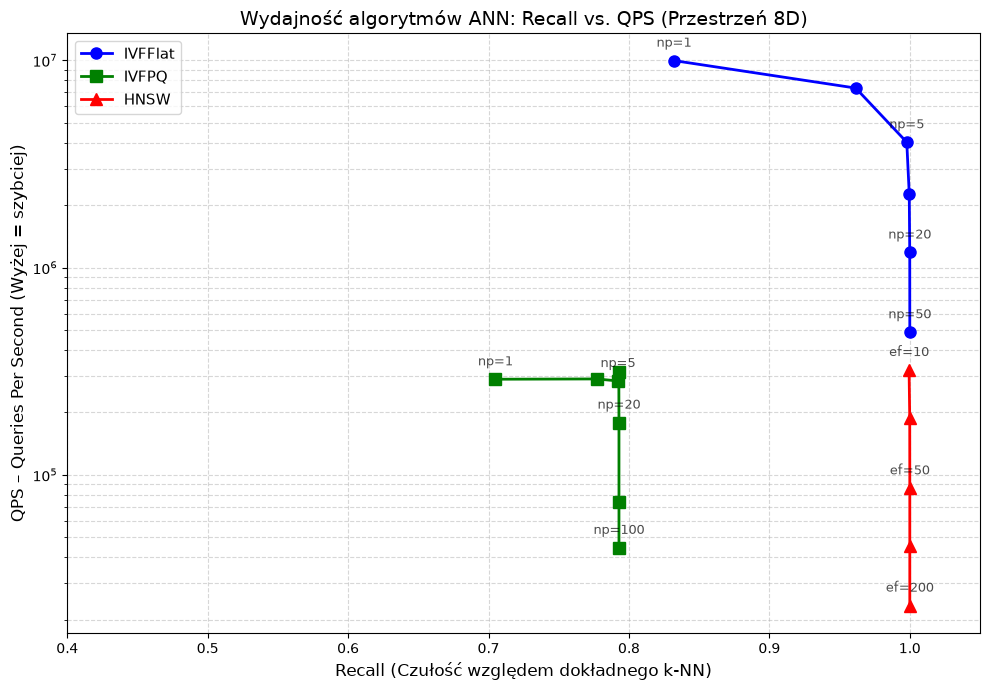

In [6]:
plt.figure(figsize=(10, 7))

colors = {"IVFFlat": "blue", "IVFPQ": "green", "HNSW": "red"}
markers = {"IVFFlat": "o", "IVFPQ": "s", "HNSW": "^"}

for name, data in results.items():
    plt.plot(data["recall"], data["qps"], 
             marker=markers[name], color=colors[name], 
             linestyle='-', linewidth=2, markersize=8, label=name)
    
    for i, label in enumerate(data["labels"]):
        if i % 2 == 0 or i == len(data["labels"]) - 1:
            plt.annotate(label, (data["recall"][i], data["qps"][i]), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, alpha=0.7)

plt.yscale("log")
plt.xlabel("Recall (Czułość względem dokładnego k-NN)", fontsize=12)
plt.ylabel("QPS – Queries Per Second (Wyżej = szybciej)", fontsize=12)

# Zaktualizowano tytuł wykresu dla przestrzeni 8D
plt.title("Wydajność algorytmów ANN: Recall vs. QPS (Przestrzeń 8D)", fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

# Rozszerzamy zakres osi X, aby lepiej uwidocznić niższe wartości recall
plt.xlim(0.4, 1.05)

plt.tight_layout()
plt.show()

=== WYSZUKIWANIE PUNKTU PRZECIĘCIA (CROSSOVER N): CPU vs GPU ===

Wczytywanie zbioru danych 1k (1000 punktów)...
 -> CPU Time: 7.11 ms
 -> GPU Time: 0.21 ms

Wczytywanie zbioru danych 10k (10000 punktów)...


WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points
WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points


 -> CPU Time: 70.09 ms
 -> GPU Time: 1.43 ms

Wczytywanie zbioru danych 100k (100000 punktów)...
 -> CPU Time: 343.70 ms
 -> GPU Time: 22.58 ms

Wczytywanie zbioru danych 1M (1000000 punktów)...
 -> CPU Time: 16290.28 ms
 -> GPU Time: 1812.27 ms


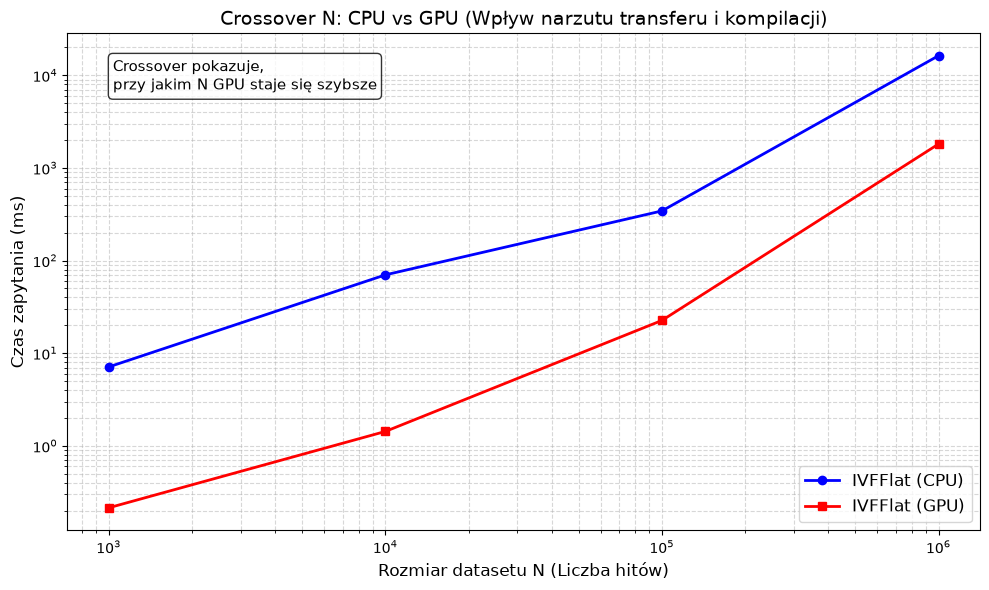

In [7]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
from hep_tracking.ann_models import FaissIVFFlat

# Parametry benchmarku
target_sizes = {"1k": 1000, "10k": 10000, "100k": 100000, "1M": 1000000}
mode = "hard"
k_neighbors = 5
nprobe = 5

cpu_times = []
gpu_times = []
valid_sizes = []

print("=== WYSZUKIWANIE PUNKTU PRZECIĘCIA (CROSSOVER N): CPU vs GPU ===")

for size_label, n_points in target_sizes.items():
    filename = data_dir / f"dataset_{mode}_{size_label}.npz"

    if not filename.exists():
        print(f"[POMINIĘTO] Plik {filename.name} nie istnieje.")
        continue

    print(f"\nWczytywanie zbioru danych {size_label} ({n_points} punktów)...")
    loaded_data = np.load(filename)
    features_5d = loaded_data["X"]

    # 1. Dopełnienie danych do 8 wymiarów (padding).
    # Zachowuje przestrzeń metryczną i poprawia wydajność na GPU.
    features_8d = np.pad(features_5d, ((0, 0), (0, 3)), mode='constant')
    features = np.ascontiguousarray(features_8d, dtype=np.float32)

    # Dla małych zbiorów danych (np. 1k) FAISS nie może utworzyć
    # dużej liczby klastrów. Zastosowano regułę empiryczną:
    # nlist = sqrt(N)
    nlist = min(100, int(np.sqrt(features.shape[0])))

    # ---------------------------------------------------------
    # 2. TEST CPU
    # ---------------------------------------------------------
    model_cpu = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=False)
    model_cpu.build(features)

    best_cpu_time = float('inf')
    for _ in range(3):
        start = time.perf_counter()
        model_cpu.query(features, k_neighbors)
        duration = time.perf_counter() - start
        best_cpu_time = min(best_cpu_time, duration)

    cpu_times.append(best_cpu_time)
    del model_cpu
    gc.collect()

    # ---------------------------------------------------------
    # 3. TEST GPU
    # ---------------------------------------------------------
    model_gpu = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=True)
    model_gpu.build(features)

    # Rozgrzanie GPU (warm-up) – wymagane przed właściwym pomiarem.
    model_gpu.query(features[:100], k_neighbors)

    best_gpu_time = float('inf')
    for _ in range(3):
        start = time.perf_counter()
        model_gpu.query(features, k_neighbors)
        # Synchronizacja GPU jest już zaimplementowana
        # wewnątrz klasy FaissIVFFlat.
        duration = time.perf_counter() - start
        best_gpu_time = min(best_gpu_time, duration)

    gpu_times.append(best_gpu_time)
    del model_gpu
    gc.collect()

    valid_sizes.append(n_points)
    print(f" -> CPU Time: {best_cpu_time*1000:.2f} ms")
    print(f" -> GPU Time: {best_gpu_time*1000:.2f} ms")

# ---------------------------------------------------------
# 4. RYSOWANIE WYKRESU
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(valid_sizes, [t * 1000 for t in cpu_times], marker='o', linewidth=2, color='blue', label='IVFFlat (CPU)')
plt.plot(valid_sizes, [t * 1000 for t in gpu_times], marker='s', linewidth=2, color='red', label='IVFFlat (GPU)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Rozmiar datasetu N (Liczba hitów)", fontsize=12)
plt.ylabel("Czas zapytania (ms)", fontsize=12)
plt.title("Crossover N: CPU vs GPU (Wpływ narzutu transferu i kompilacji)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)

# Dodanie krótkiej adnotacji wyjaśniającej wykres
plt.text(
    0.05,
    0.95,
    "Crossover pokazuje,\nprzy jakim N GPU staje się szybsze",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

=== WYZNACZANIE RZECZYWISTEGO PUNKTU CROSSOVER N (< 1000) ===
N=10: CPU = 0.030 ms | GPU = 0.062 ms
N=100: CPU = 0.509 ms | GPU = 0.073 ms
N=200: CPU = 0.781 ms | GPU = 0.084 ms
N=500: CPU = 1.903 ms | GPU = 0.112 ms
N=1000: CPU = 3.608 ms | GPU = 0.166 ms


WARNING clustering 10 points to 3 centroids: please provide at least 117 training points
WARNING clustering 10 points to 3 centroids: please provide at least 117 training points
WARNING clustering 100 points to 10 centroids: please provide at least 390 training points
WARNING clustering 100 points to 10 centroids: please provide at least 390 training points
WARNING clustering 200 points to 14 centroids: please provide at least 546 training points
WARNING clustering 200 points to 14 centroids: please provide at least 546 training points
WARNING clustering 500 points to 22 centroids: please provide at least 858 training points
WARNING clustering 500 points to 22 centroids: please provide at least 858 training points
WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points
WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points


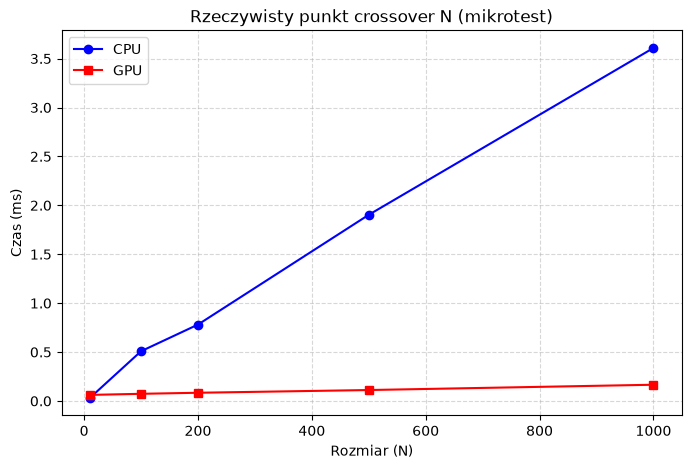

In [8]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
from hep_tracking.ann_models import FaissIVFFlat

# Wczytanie tylko zbioru danych 1k
filename = data_dir / f"dataset_hard_1k.npz"
loaded_data = np.load(filename)
features_5d = loaded_data["X"]
features_8d = np.pad(features_5d, ((0, 0), (0, 3)), mode='constant')
features_full = np.ascontiguousarray(features_8d, dtype=np.float32)

micro_sizes = [10, 100, 200, 500, 1000]
cpu_micro = []
gpu_micro = []

print("=== WYZNACZANIE RZECZYWISTEGO PUNKTU CROSSOVER N (< 1000) ===")

for size in micro_sizes:
    # Wybór odpowiedniego fragmentu danych
    features = features_full[:size]
    nlist = min(100, int(np.sqrt(features.shape[0])))

    # --- CPU ---
    model_cpu = FaissIVFFlat(nlist=nlist, nprobe=5, use_gpu=False)
    model_cpu.build(features)
    best_cpu = float('inf')
    for _ in range(5):
        start = time.perf_counter()
        model_cpu.query(features, k_neighbors)
        best_cpu = min(best_cpu, time.perf_counter() - start)
    cpu_micro.append(best_cpu * 1000)  # czas w ms
    del model_cpu

    # --- GPU ---
    model_gpu = FaissIVFFlat(nlist=nlist, nprobe=5, use_gpu=True)
    model_gpu.build(features)

    # Rozgrzanie GPU (warm-up)
    model_gpu.query(features[:10], k_neighbors)

    best_gpu = float('inf')
    for _ in range(5):
        start = time.perf_counter()
        model_gpu.query(features, k_neighbors)
        best_gpu = min(best_gpu, time.perf_counter() - start)
    gpu_micro.append(best_gpu * 1000)  # czas w ms
    del model_gpu

    print(f"N={size}: CPU = {best_cpu*1000:.3f} ms | GPU = {best_gpu*1000:.3f} ms")

plt.figure(figsize=(8, 5))
plt.plot(micro_sizes, cpu_micro, marker='o', color='blue', label='CPU')
plt.plot(micro_sizes, gpu_micro, marker='s', color='red', label='GPU')
plt.xlabel("Rozmiar (N)")
plt.ylabel("Czas (ms)")
plt.title("Rzeczywisty punkt crossover N (mikrotest)")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()

In [ ]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# --- USTAWIENIE ŚCIEŻEK ---
# Automatycznie znajdujemy folder z danymi oraz kodem źródłowym
project_root = Path().resolve().parent
data_dir = project_root / "data"
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from hep_tracking.ann_models import FaissIVFFlat, FaissIVFPQ, HnswGraph

# --- KONFIGURACJA EKSPERYMENTU ---
USE_GPU = True 

target_sizes = {"1k": 1000, "10k": 10000, "100k": 100000, "1M": 1000000}
mode = "hard"
k_neighbors = 5

# Dobrane parametry, aby uzyskać Recall na poziomie około ~95%
params = {
    "IVFFlat": {"nprobe": 20},
    "IVFPQ": {"nprobe": 50, "m": 4},
    "HNSW": {"ef": 50, "m_graph": 16}
}

results_time = {"IVFFlat": [], "IVFPQ": [], "HNSW": []}
valid_sizes = []

print(f"=== START EKSPERYMENTU: TIME vs N (USE_GPU={USE_GPU}) ===")

for size_label, n_points in target_sizes.items():
    dataset_path = data_dir / f"dataset_{mode}_{size_label}.npz"
    if not dataset_path.exists():
        print(f"[POMIJAM] Nie znaleziono pliku {size_label}: {dataset_path}")
        continue
        
    print(f"\nŁadowanie zbioru danych {size_label}...")
    features_5d = np.load(dataset_path)["X"]
    
    # Trik z Zero-Padding (rozszerzenie do 8D) dla lepszej kompatybilności
    features_8d = np.pad(features_5d, ((0, 0), (0, 3)), mode='constant')
    # FAISS wymaga ciągłości w pamięci (C-contiguous) i formatu float32
    features = np.ascontiguousarray(features_8d, dtype=np.float32)
    
    # Parametr nlist: zalecana wartość to pierwiastek kwadratowy z liczby punktów
    nlist = min(100, int(np.sqrt(features.shape[0])))
    valid_sizes.append(n_points)
    
    # --- 1. Algorytm IVFFlat ---
    model_ivf = FaissIVFFlat(nlist=nlist, nprobe=params["IVFFlat"]["nprobe"], use_gpu=USE_GPU)
    model_ivf.build(features)
    
    start = time.perf_counter()
    model_ivf.query(features, k_neighbors)
    results_time["IVFFlat"].append(time.perf_counter() - start)
    
    del model_ivf
    gc.collect() # Czyszczenie pamięci przed kolejnym testem

    # --- 2. Algorytm IVFPQ (z kompresją) ---
    model_pq = FaissIVFPQ(nlist=nlist, m=params["IVFPQ"]["m"], nprobe=params["IVFPQ"]["nprobe"], use_gpu=USE_GPU)
    model_pq.build(features)
    
    start = time.perf_counter()
    model_pq.query(features, k_neighbors)
    results_time["IVFPQ"].append(time.perf_counter() - start)
    
    del model_pq
    gc.collect()

    # --- 3. Algorytm HNSW (grafowy) ---
    model_hnsw = HnswGraph(m=params["HNSW"]["m_graph"], ef_construction=200, ef=params["HNSW"]["ef"])
    model_hnsw.build(features)
    
    start = time.perf_counter()
    model_hnsw.query(features, k_neighbors)
    results_time["HNSW"].append(time.perf_counter() - start)
    
    del model_hnsw
    gc.collect()
    
    print(f" -> Zbiór {size_label} został przetworzony.")

# --- RYSOWANIE WYKRESU ---
plt.figure(figsize=(10, 6))

plt.plot(valid_sizes, results_time["IVFFlat"], marker='o', color='blue', linewidth=2, label='IVFFlat (CPU)')
plt.plot(valid_sizes, results_time["IVFPQ"], marker='s', color='green', linewidth=2, label='IVFPQ (CPU)')
plt.plot(valid_sizes, results_time["HNSW"], marker='^', color='red', linewidth=2, label='HNSW (CPU)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Rozmiar zbioru danych N (Liczba hitów)", fontsize=12)
plt.ylabel("Czas zapytania (sekundy)", fontsize=12)
plt.title("Wydajność algorytmów ANN: Czas vs N (Przy stałym Recall ~95%)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

=== START EKSPERYMENTU: TIME vs N (USE_GPU=True) ===

Ładowanie zbioru danych 1k...


WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points
WARNING clustering 995 points to 31 centroids: please provide at least 1209 training points
WARNING clustering 995 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 995 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 995 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 995 points to 256 centroids: please provide at least 9984 training points


 -> Zbiór 1k został przetworzony.

Ładowanie zbioru danych 10k...
 -> Zbiór 10k został przetworzony.

Ładowanie zbioru danych 100k...
 -> Zbiór 100k został przetworzony.

Ładowanie zbioru danych 1M...
